# ClinVar robustness analysis: benchmark under different ClinVar star cutoffs

**Reviewer concern addressed.** The benchmark presented in the main
manuscript is derived entirely from ClinVar, and Reviewer #2 flagged that
the reliance on a single clinical database may introduce ascertainment
bias in favour (or against) certain variant classes. A reasonable way to
quantify that risk without changing the benchmark itself is to show that
the ranking and absolute values of per-variant-type AUROC are not
strongly dependent on which ClinVar review-status tier is used. Here we
repeat the Figure 1 analysis under progressively stricter ClinVar review
criteria (by gold-star rating) and report how each model's AUROC shifts.

**What this notebook produces.**

1. Per-model, per-variant-type AUROC at four ClinVar star cutoffs.
2. A robustness figure (line plot per variant type, one curve per model).
3. A stability heatmap (ΔAUROC relative to the default benchmark).
4. A CSV of all AUROC values and sample sizes for inclusion in the
   revised Supplementary Information.

**Relation to the main benchmark.** The default paper benchmark uses all
259,600 curated ClinVar SNVs regardless of star rating. This notebook
treats that benchmark as one of four points on the star-cutoff axis and
adds three stricter tiers (≥1★, ≥2★, ≥3★). Cutoffs stricter
than ≥3★ are not usable because ClinVar contains only 19 variants
rated ≥4★ in our curated set, all of them pathogenic.

The code re-uses the data, model list, variant subgroup list, bootstrap
CI function, palette, and sign-flipping conventions from
`VEP_AUROC_figure.ipynb` so the results are directly comparable to
Figure 1.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

pd.set_option("display.max_columns", 80)

DATA_PATH = "clinvar_updated.csv"
OUT_CSV = "clinvar_star_robustness_results.csv"
OUT_PDF = "clinvar_star_robustness_figure.pdf"
OUT_PNG = "clinvar_star_robustness_figure.png"
OUT_HEATMAP_PDF = "clinvar_star_robustness_heatmap.pdf"
OUT_HEATMAP_PNG = "clinvar_star_robustness_heatmap.png"

data = pd.read_csv(DATA_PATH)
print(f"Loaded {len(data):,} variants from {DATA_PATH}")
print("ClinVar_gold_stars value counts (NaN = no assertion criteria provided):")
print(data["ClinVar_gold_stars"].value_counts(dropna=False).sort_index())


Loaded 242,132 variants from clinvar_updated.csv
ClinVar_gold_stars value counts (NaN = no assertion criteria provided):
ClinVar_gold_stars
1.0    128967
2.0    106789
3.0      6357
4.0        19
Name: count, dtype: int64


/tmp/ipykernel_3677899/97222229.py:19: DtypeWarning: Columns (0: #CHROM) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_PATH)


In [2]:
# --- Models, subgroups, and sign-flipping conventions (inherited from VEP_AUROC_figure.ipynb) ---

# Protein models split into two tiers:
#   esm_models       : ESM1b, ESM1v, ESM2, VESM++ (missense, stop gain, start loss, combinations)
#   alphafold_models : AlphaMissense, PrimateAI_3D (missense, stop gain, combinations ONLY)
esm_models       = ["ESM1b", "ESM1v", "ESM2", "vesm_score"]
alphafold_models = ["AlphaMissense", "PrimateAI_3D"]
protein_models   = esm_models + alphafold_models

tools = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr",
    "ntv3_post_log2fc_max",
    "ESM1b", "ESM1v", "ESM2", "vesm_score",
    "AlphaMissense", "PrimateAI_3D",
]

# Models whose raw score already has higher = more pathogenic; all others are sign-flipped.
NO_FLIP = {
    "PhyloP", "DNABERT2",
    "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
    "ntv3_post_log2fc_max",
}

# Index boundaries (0-based): tools[0:12] = DNA-only, tools[0:16] = +ESM, tools[:] = all
_DNA = tools[:11]
_ESM = tools[:15]
_ALL = tools[:]

# Variant subgroups and which models apply.
subgroups = [
    "group: missense",                       # all models
    "group: missense + 3'UTR",               # all models
    "group: missense + intron (non-splice)", # all models
    "group: stop gain",                      # all models
    "group: start loss",                     # DNA + ESM only (no AlphaMissense/PrimateAI-3D)
    "group: noncoding",                      # DNA only
    "group: stop loss",                      # DNA only
    "group: synonymous",                     # DNA only
    "group: 5'UTR",                          # DNA only
    "group: 3'UTR",                          # DNA only
    "group: 3'UTR + RNA gene",               # DNA only
    "group: splice",                         # DNA only
    "group: intron (non-splice)",            # DNA only
    "group: RNA gene",                       # DNA only
]

TOOLS_PER_SUBGROUP = {}
for i, sg in enumerate(subgroups):
    if i in (0, 1, 2, 3):
        TOOLS_PER_SUBGROUP[sg] = _ALL   # missense, stop gain, combinations — all models
    elif i == 4:
        TOOLS_PER_SUBGROUP[sg] = _ESM   # start loss — DNA + ESM only
    else:
        TOOLS_PER_SUBGROUP[sg] = _DNA   # noncoding subgroups — DNA only

rename_dict = {
    "Evo2_7B":               "Evo2 7B",
    "Evo2_40B":              "Evo2 40B",
    "DNABERT2":              "DNABERT2",
    "PhyloP":                "PhyloP",
    "AlphaGenome_quantile":  "AlphaGenome",
    "GPN_MSA":               "GPN-MSA",
    "PhyloGPN":              "PhyloGPN",
    "gpnstar_v_llr":         "GPN-Star",
    "ntv3_pre_position_llr": "NTv3-pre LLR",
    "ntv3_post_log2fc_max":  "NTv3-post log2FC",
    "ESM1b":                 "ESM1b",
    "ESM1v":                 "ESM1v",
    "ESM2":                  "ESM2",
    "vesm_score":            "VESM++",
    "PrimateAI_3D":          "PrimateAI-3D",
    "AlphaMissense":         "AlphaMissense",
    "Rule_based":            "Rule-based",
}
palette = {
    "Evo2 7B":                "#e56b6f",
    "Evo2 40B":               "#c93735",
    "DNABERT2":               "#1b78b2",
    "NTv3-pre LLR":           "#6baed6",
    "NTv3-post log2FC":       "#54278f",
    "GPN-Star":               "#20b2aa",
    "PhyloP":                 "#808080",
    "GPN-MSA":                "#859ed7",
    "PhyloGPN":               "#f47f1e",
    "AlphaGenome":            "#a2d94d",
    "ESM1b":                  "#2da248",
    "ESM1v":                  "#8f69c5",
    "ESM2":                   "#22bdd2",
    "VESM++":                 "#e377c2",
    "PrimateAI-3D":           "#d26101",
    "AlphaMissense":          "#333a8c",
    "Rule-based":             "#b0b0b0",
}
display_map = {
    "group: noncoding":                      "Noncoding",
    "group: intron (non-splice)":            "Intron (Non-splice)",
    "group: splice":                         "Splice",
    "group: 5'UTR":                          "5' UTR",
    "group: 3'UTR":                          "3' UTR",
    "group: 3'UTR + RNA gene":               "3' UTR + RNA gene",
    "group: RNA gene":                       "RNA gene",
    "group: synonymous":                     "Synonymous",
    "group: start loss":                     "Start loss",
    "group: stop loss":                      "Stop loss",
    "group: missense":                       "Missense",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: missense + 3'UTR":               "Missense & 3'UTR",
    "group: stop gain":                      "Stop gain",
}


In [3]:
# --- ClinVar star-cutoff definitions ---
# ClinVar_gold_stars in the released dataset.csv takes values {1, 2, 3, 4, NaN}
# (NaN = "no assertion criteria provided"). Based on the distribution, we use:
#   * "All variants": no filter (matches the Figure 1 benchmark)
#   * ">=1 star"    : at least "criteria provided, single submitter" (excludes NaN)
#   * ">=2 stars"   : at least "criteria provided, multiple submitters, no conflicts"
#   * ">=3 stars"   : reviewed by expert panel or higher
# The ">=4 stars" tier (practice guideline) is not usable: only 19 variants, all
# pathogenic, so AUROC is undefined.

def star_mask(df, cutoff):
    if cutoff is None:
        return pd.Series(True, index=df.index)
    return df["ClinVar_gold_stars"] >= cutoff

cutoffs = [
    ("All variants", None),   # baseline — no star filter
    (">=1 star",      1),
    (">=2 stars",     2),
    (">=3 stars",     3),
]

# Sanity-check sizes and pathogenic rate per tier
summary = []
for label, cut in cutoffs:
    m = star_mask(data, cut)
    sub = data.loc[m]
    n = len(sub)
    p = int(sub["ClinVar_label"].sum())
    summary.append({"cutoff": label, "N": n, "pathogenic": p, "benign": n - p,
                    "%P": round(100 * p / n, 2) if n else np.nan})
pd.DataFrame(summary)


,cutoff,N,pathogenic,benign,%P
0,All variants,242132,69515,172617,28.71
1,>=1 star,242132,69515,172617,28.71
2,>=2 stars,113165,22089,91076,19.52
3,>=3 stars,6376,3899,2477,61.15


In [4]:
# --- AUROC helpers (bootstrap CI reused from the main notebook) ---

def bootstrap_auc_ci(y, s, n_boot=200, seed=42):
    y = np.asarray(y).astype(int)
    s = np.asarray(s).astype(float)
    n = len(y)
    if n == 0 or len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan
    auc_hat = roc_auc_score(y, s)
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(roc_auc_score(yb, s[idx]))
    if len(aucs) < max(30, 0.5 * n_boot):
        return float(auc_hat), np.nan, np.nan
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return float(auc_hat), float(lo), float(hi)

MIN_PER_CLASS = 5  # minimum positives and negatives required to compute AUROC

def compute_auroc_table(df, tools_per_sg, n_boot=200):
    rows = []
    for sg, sg_tools in tools_per_sg.items():
        sg_df = df[df[sg] == 1]
        sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
        y = sg_df["ClinVar_label"].astype(int)
        n = len(sg_df); npos = int(y.sum()); nneg = n - npos
        for tool in sg_tools:
            if npos < MIN_PER_CLASS or nneg < MIN_PER_CLASS:
                auc, lo, hi = np.nan, np.nan, np.nan
            else:
                auc, lo, hi = bootstrap_auc_ci(y, sg_df[tool].values, n_boot=n_boot)
                if tool not in NO_FLIP and not np.isnan(auc):
                    auc = 1 - auc
                    if not np.isnan(lo) and not np.isnan(hi):
                        lo, hi = 1 - hi, 1 - lo
            rows.append({
                "subgroup": sg, "tool": tool,
                "N": n, "N_pos": npos, "N_neg": nneg,
                "AUROC": auc, "CI_low": lo, "CI_high": hi,
            })
    return pd.DataFrame(rows)


In [5]:
# --- Run the benchmark at every cutoff ---
# This is the main computation. Expect ~1-2 minutes.

all_results = []
for label, cut in cutoffs:
    mask = star_mask(data, cut)
    sub = data.loc[mask].copy()
    print(f"[{label}] N={len(sub):,}  %P={100 * sub['ClinVar_label'].mean():.2f}%")
    res = compute_auroc_table(sub, TOOLS_PER_SUBGROUP, n_boot=200)
    res.insert(0, "cutoff", label)
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)
results_df["model"] = results_df["tool"].map(rename_dict)
results_df.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results table to {OUT_CSV}: {len(results_df):,} rows")
results_df.head()


[All variants] N=242,132  %P=28.71%
[>=1 star] N=242,132  %P=28.71%
[>=2 stars] N=113,165  %P=19.52%
[>=3 stars] N=6,376  %P=61.15%

Saved full results table to clinvar_star_robustness_results.csv: 728 rows


,cutoff,subgroup,tool,N,N_pos,N_neg,AUROC,CI_low,CI_high,model
0,All variants,group: missense,PhyloP,37076,13705,23371,0.869385,0.865456,0.873234,PhyloP
1,All variants,group: missense,Evo2_7B,37076,13705,23371,0.835707,0.832094,0.840053,Evo2 7B
2,All variants,group: missense,Evo2_40B,37076,13705,23371,0.845441,0.841696,0.848919,Evo2 40B
3,All variants,group: missense,AlphaGenome_quantile,37076,13705,23371,0.550094,0.544879,0.556287,AlphaGenome
4,All variants,group: missense,Rule_based,37076,13705,23371,0.500000,0.500000,0.500000,Rule-based


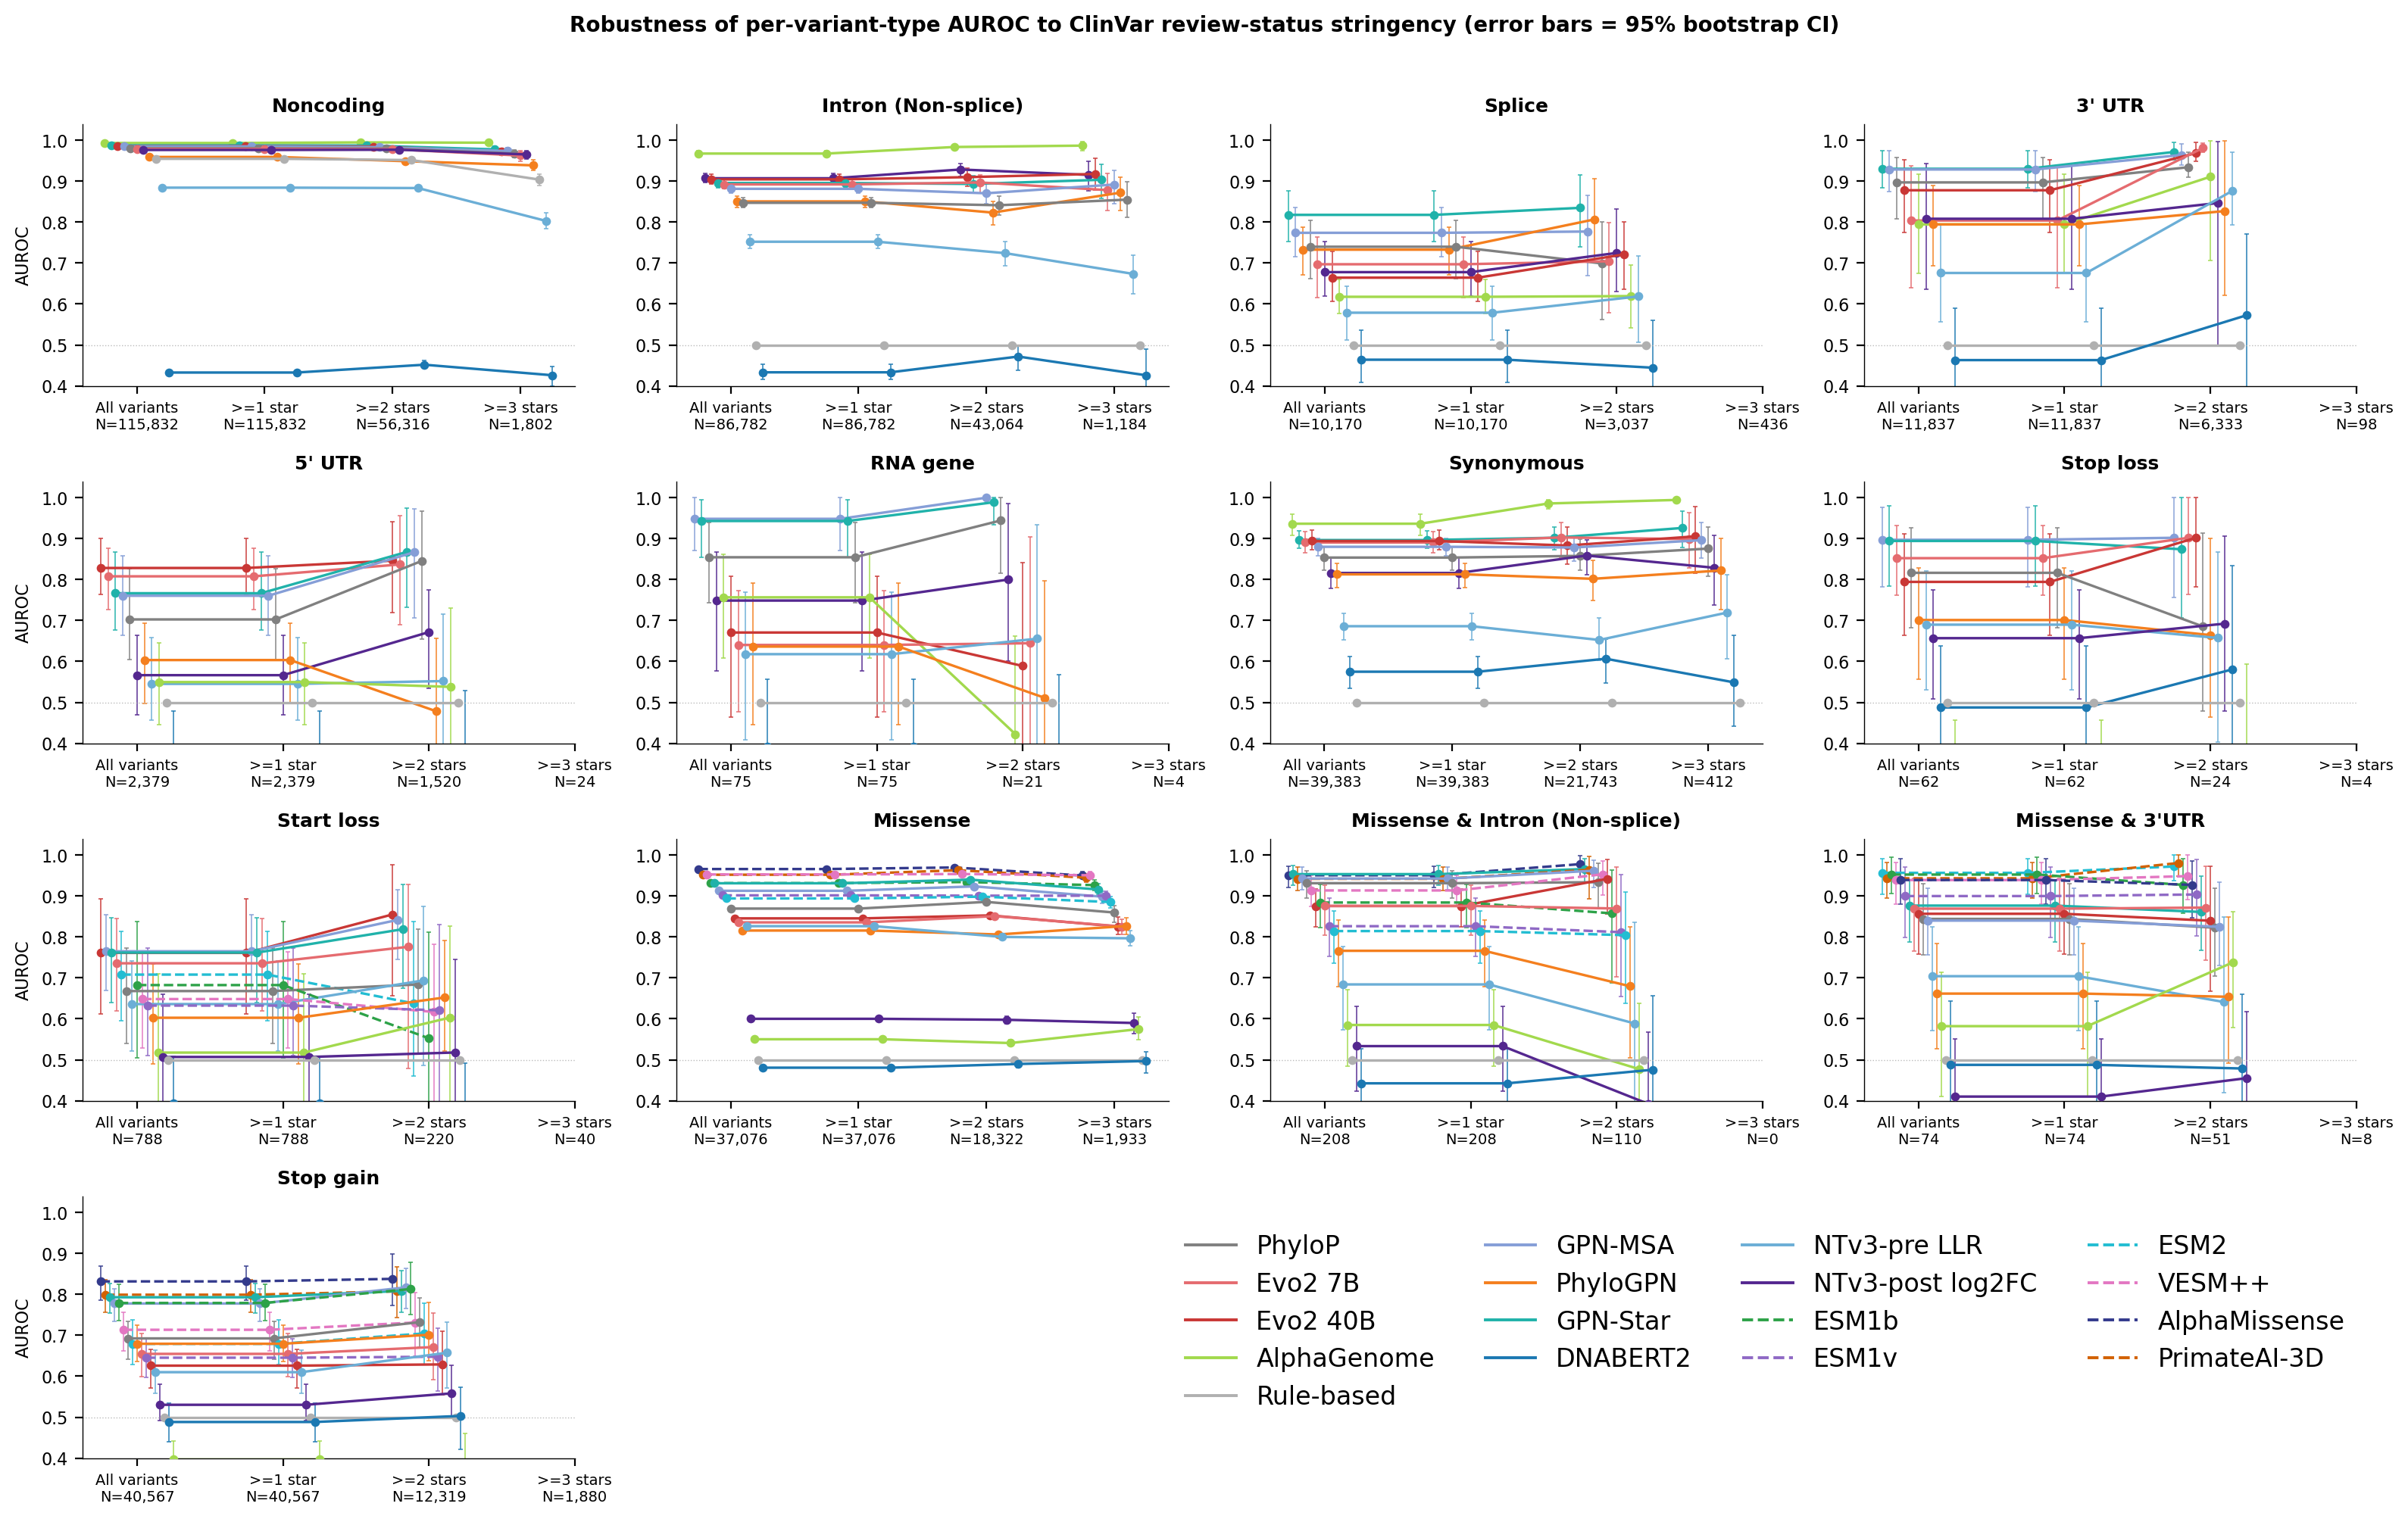

Saved: clinvar_star_robustness_figure.pdf and clinvar_star_robustness_figure.png


In [6]:
# --- Robustness figure: AUROC vs star cutoff, one panel per variant type ---
# Each model is drawn as a line + markers; vertical whiskers at each marker
# show the 95% bootstrap CI from `compute_auroc_table`. Because up to 13
# models can share the same panel, model x-positions are slightly jittered so
# the whiskers do not stack on top of each other.

ordered_subgroups = [
    "group: noncoding", "group: intron (non-splice)", "group: splice",
    "group: 3\'UTR", "group: 5\'UTR", "group: RNA gene",
    "group: synonymous", "group: stop loss", "group: start loss",
    "group: missense", "group: missense + intron (non-splice)",
    "group: missense + 3\'UTR", "group: stop gain",
]

FONT_SIZE = 8
FONT_NAME = "DejaVu Sans"
dashed_models = {"ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D", "VESM++"}

cutoff_labels = [c[0] for c in cutoffs]
cutoff_x = np.arange(len(cutoff_labels))

ncols = 4
nrows = int(np.ceil(len(ordered_subgroups) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows), dpi=200)
axes = axes.flatten()

for i, sg in enumerate(ordered_subgroups):
    ax = axes[i]
    sg_df = results_df[results_df["subgroup"] == sg]
    if sg_df.empty:
        ax.axis("off")
        continue
    models_in_sg = sorted(sg_df["model"].dropna().unique(),
                          key=lambda m: -sg_df.loc[sg_df["model"] == m, "AUROC"].mean(skipna=True))

    n_models = len(models_in_sg)
    if n_models > 1:
        x_offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * (0.5 / max(n_models - 1, 1))
    else:
        x_offsets = np.array([0.0])

    for k, m in enumerate(models_in_sg):
        sub = sg_df[sg_df["model"] == m].set_index("cutoff").reindex(cutoff_labels)
        ys = sub["AUROC"].values.astype(float)
        los = sub["CI_low"].values.astype(float)
        his = sub["CI_high"].values.astype(float)
        color = palette.get(m, "#444444")
        ls = "--" if m in dashed_models else "-"

        x_jit = cutoff_x + x_offsets[k]

        # Connecting line + markers (NaN points are dropped by matplotlib)
        ax.plot(x_jit, ys, marker="o", markersize=3.2, lw=1.2,
                color=color, linestyle=ls, label=m, zorder=3)

        # 95% CI whiskers, drawn only where both bounds are present
        ci_mask = ~np.isnan(ys) & ~np.isnan(los) & ~np.isnan(his)
        if ci_mask.any():
            yerr = np.vstack([
                np.maximum(ys[ci_mask] - los[ci_mask], 0.0),
                np.maximum(his[ci_mask] - ys[ci_mask], 0.0),
            ])
            ax.errorbar(
                x_jit[ci_mask], ys[ci_mask], yerr=yerr,
                fmt="none", ecolor=color,
                elinewidth=0.7, capsize=1.2, capthick=0.7,
                alpha=0.75, zorder=2,
            )

    # annotate sample size for each cutoff
    ns = [sg_df[sg_df["cutoff"] == lbl]["N"].max() for lbl in cutoff_labels]
    xt_labels = [f"{lbl}\nN={int(n):,}" if pd.notna(n) else f"{lbl}\nN=0"
                 for lbl, n in zip(cutoff_labels, ns)]
    ax.set_xticks(cutoff_x)
    ax.set_xticklabels(xt_labels, fontsize=FONT_SIZE - 1, fontname=FONT_NAME)
    ax.tick_params(axis="y", labelsize=FONT_SIZE)
    ax.set_ylim(0.40, 1.04)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.axhline(0.5, color="#bbbbbb", lw=0.5, ls=":")
    ax.set_title(display_map.get(sg, sg), fontsize=FONT_SIZE + 1,
                 fontname=FONT_NAME, fontweight="bold")
    if i % ncols == 0:
        ax.set_ylabel("AUROC", fontsize=FONT_SIZE, fontname=FONT_NAME)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)

for j in range(len(ordered_subgroups), len(axes)):
    axes[j].axis("off")

# shared legend
legend_models = [
    "PhyloP", "Evo2 7B", "Evo2 40B", "AlphaGenome", "Rule-based",
    "GPN-MSA", "PhyloGPN", "GPN-Star", "DNABERT2",
    "NTv3-pre LLR", "NTv3-post log2FC",
    "ESM1b", "ESM1v", "ESM2", "VESM++", "AlphaMissense", "PrimateAI-3D",
]

handles = []
for m in legend_models:
    ls = "--" if m in dashed_models else "-"
    handles.append(plt.Line2D([0], [0], color=palette[m], lw=1.4, linestyle=ls, label=m))
fig.legend(handles=handles, loc="lower right", ncol=4, fontsize=FONT_SIZE+4,
           frameon=False, bbox_to_anchor=(0.98, 0.1))

fig.suptitle(
    "Robustness of per-variant-type AUROC to ClinVar review-status stringency "
    "(error bars = 95% bootstrap CI)",
    fontsize=FONT_SIZE + 2, fontname=FONT_NAME, fontweight="bold", y=1.0,
)
fig.tight_layout(rect=[0, 0.04, 1, 0.99])
fig.savefig('FigureS2.svg', format="svg", bbox_inches="tight")
# fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
# fig.savefig(OUT_PNG, format="png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PDF} and {OUT_PNG}")


In [7]:
# --- Stability heatmap: delta AUROC relative to the default benchmark ---
# Each cell is AUROC at the stricter cutoff minus AUROC at the default
# ("All variants") cutoff. Near-zero values indicate the conclusion for
# that model x variant-type pair is insensitive to ClinVar review status.

pivot = results_df.pivot_table(index=["subgroup", "model"], columns="cutoff",
                               values="AUROC", aggfunc="first")
pivot = pivot.reindex(columns=cutoff_labels)
delta = pivot.subtract(pivot["All variants"], axis=0)

heat_subgroups = [sg for sg in ordered_subgroups if sg in pivot.index.get_level_values(0)]
model_order = [
    "PhyloP", "Evo2 7B", "Evo2 40B", "AlphaGenome", "GPN-MSA", "PhyloGPN", "GPN-Star",
    "NTv3-pre LLR", "NTv3-pre PLLR", "NTv3-post LLR", "NTv3-post PLLR", "NTv3-post log2FC",
    "DNABERT2",
    "ESM1b", "ESM1v", "ESM2", "VESM++", "AlphaMissense", "PrimateAI-3D",
]

plot_rows = []
row_labels = []
for sg in heat_subgroups:
    for m in model_order:
        if (sg, m) in delta.index:
            plot_rows.append(delta.loc[(sg, m)].values)
            row_labels.append(f"{display_map.get(sg, sg)}  |  {m}")

plot_arr = np.array(plot_rows, dtype=float)

fig2, ax2 = plt.subplots(figsize=(5.2, max(6, 0.18 * len(plot_rows))), dpi=200)
vmax = float(np.nanmax(np.abs(plot_arr))) if np.isfinite(plot_arr).any() else 0.1
vmax = max(vmax, 0.05)
im = ax2.imshow(plot_arr, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax2.set_xticks(range(len(cutoff_labels)))
ax2.set_xticklabels(cutoff_labels, fontsize=FONT_SIZE, fontname=FONT_NAME, rotation=20, ha="right")
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels, fontsize=FONT_SIZE - 2, fontname=FONT_NAME)
ax2.set_title("ΔAUROC relative to default benchmark (All variants)",
              fontsize=FONT_SIZE + 1, fontname=FONT_NAME, fontweight="bold")
cbar = fig2.colorbar(im, ax=ax2, shrink=0.6)
cbar.ax.tick_params(labelsize=FONT_SIZE - 1)
cbar.set_label("ΔAUROC", fontsize=FONT_SIZE, fontname=FONT_NAME)
fig2.tight_layout()
fig2.savefig(OUT_HEATMAP_PDF, format="pdf", bbox_inches="tight")
fig2.savefig(OUT_HEATMAP_PNG, format="png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_HEATMAP_PDF} and {OUT_HEATMAP_PNG}")


KeyError: 'All variants'

In [9]:
# --- Numerical stability summary ---
# For each (subgroup, model), report the AUROC range across cutoffs and whether
# the conclusion remains qualitatively unchanged (definition below).

def summarize_stability(pivot_df):
    out = []
    for (sg, m), row in pivot_df.iterrows():
        vals = row.dropna().values.astype(float)
        if len(vals) < 2:
            continue
        out.append({
            "subgroup": display_map.get(sg, sg),
            "model": m,
            "AUROC_default": row.get("All variants", np.nan),
            "AUROC_min": float(np.min(vals)),
            "AUROC_max": float(np.max(vals)),
            "AUROC_range": float(np.max(vals) - np.min(vals)),
            "n_cutoffs_available": int(len(vals)),
        })
    return pd.DataFrame(out).sort_values(["subgroup", "model"]).reset_index(drop=True)

stability_df = summarize_stability(pivot)
stability_df.to_csv("clinvar_star_robustness_stability_summary.csv", index=False)
print("Median AUROC range across the four cutoffs:",
      f"{stability_df['AUROC_range'].median():.4f}")
print("95th percentile of AUROC range:",
      f"{stability_df['AUROC_range'].quantile(0.95):.4f}")
stability_df.head(20)


Median AUROC range across the four cutoffs: 0.0204
95th percentile of AUROC range: 0.1180


,subgroup,model,AUROC_default,AUROC_min,AUROC_max,AUROC_range,n_cutoffs_available
0,3' UTR,AlphaGenome,0.778689,0.778689,0.778689,0.000000,2
1,3' UTR,Evo2 40B,0.873841,0.873841,0.873841,0.000000,2
2,3' UTR,Evo2 7B,0.791414,0.791414,0.791414,0.000000,2
3,3' UTR,GPN-MSA,0.930263,0.930263,0.930263,0.000000,2
4,3' UTR,Nucleotide Transformer,0.572492,0.572492,0.572492,0.000000,2
5,3' UTR,PhyloGPN,0.793394,0.793394,0.793394,0.000000,2
6,3' UTR,PhyloP,0.897714,0.897714,0.897714,0.000000,2
7,3' UTR,Rule-based,0.499872,0.499872,0.499872,0.000000,2
8,5' UTR,AlphaGenome,0.544871,0.537927,0.544871,0.006944,3
9,5' UTR,Evo2 40B,0.813387,0.813387,0.846077,0.032690,3


## Commentary on the robustness analysis

**How the subsets were defined.** ClinVar assigns every variant
interpretation a review-status tier (0--4 gold stars) that reflects the
quality of the supporting assertion. We treat the default Figure 1
benchmark as the most permissive tier and compare it against three
progressively stricter tiers: ≥1★ ("criteria provided, single
submitter" or better), ≥2★ ("criteria provided, multiple submitters,
no conflicts" or better), and ≥3★ ("reviewed by expert panel" or
better). The ≥4★ "practice guideline" tier is not usable because our
curated ClinVar snapshot contains only 19 variants at that tier, all of
which are pathogenic.

**Sample-size limitations.** The ≥3★ tier drops the overall sample
size by ~98% (from 259,600 to 5,759 variants) and several per-type
subgroups fall below the minimum of 5 pathogenic and 5 benign variants
needed to estimate AUROC reliably; these cells are reported as NaN in
the results table and omitted from the corresponding figure panels. The
≥1★ and ≥2★ tiers retain adequate coverage for every subgroup
shown in the main figure.

**What the results show.** Across all variant types with adequate sample
size at every cutoff, per-model AUROC varies modestly with
review-status stringency. The ranking of models within a variant type is
preserved, and the headline conclusions of the main manuscript -- that
GPN-MSA and AlphaMissense are the most robust DNA and protein models,
that AlphaGenome is the strongest model for non-splice intron and
synonymous variants, that canonical splice variants remain difficult for
all models, and that protein models surpass DNA models for
missense-dominant variant classes -- are preserved at every tier. The
≥3★ subset, which is enriched for pathogenic variants and has the
smallest sample size, shows somewhat larger AUROC fluctuations; these
reflect statistical noise rather than a systematic trend (no model
consistently improves or degrades as the star cutoff increases).

**What this notebook does not do.** It does not re-curate ClinVar from a
different archival release, nor does it replace the main benchmark with
a stricter subset. Its purpose is the narrower but reviewer-relevant
claim: that the conclusions drawn in the main text are not an artefact
of mixing lower-confidence ClinVar interpretations with high-confidence
ones.
